In [2]:
!pip install prophet
!pip install xgboost
!pip install statsmodels
!pip install plotly
!pip install streamlit

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [4]:
import os

print(os.getcwd())

C:\Users\Acer


In [10]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\Acer\Desktop\SalesForecasting_Akshitha
['train.csv', 'train.csv (1).zip', 'vgsales.csv', 'vgsales.csv.zip']


In [13]:
sales_df = pd.read_csv("train.csv")
games_df = pd.read_csv(r"vgsales.csv\vgsales.csv")

sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [14]:
sales_df.shape

(9800, 18)

### Observation

The dataset contains 9800 rows and 18 columns. It includes order details, customer information, product details, shipping information, and sales values, making it suitable for sales forecasting and business analysis.

In [ ]:
df.head()

In [15]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

### Observation

The dataset contains both numerical and categorical features. The Order Date and Ship Date columns are currently stored as object type and need to be converted into datetime format for time series analysis.

In [ ]:
df.describe()

In [16]:
sales_df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

### Observation

The dataset contains very few missing values. The Postal Code column has some missing entries, while the remaining columns are complete.

In [17]:
sales_df.duplicated().sum()

0

### Observation

Duplicate records were checked to ensure data quality before performing analysis.

In [18]:
sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    dayfirst=True
)

sales_df["Ship Date"] = pd.to_datetime(
    sales_df["Ship Date"],
    dayfirst=True
)

sales_df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

In [19]:
sales_df["Year"] = sales_df["Order Date"].dt.year
sales_df["Month"] = sales_df["Order Date"].dt.month
sales_df["Week"] = sales_df["Order Date"].dt.isocalendar().week
sales_df["DayOfWeek"] = sales_df["Order Date"].dt.day_name()
sales_df["Quarter"] = sales_df["Order Date"].dt.quarter

In [20]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

sales_df["Season"] = sales_df["Month"].apply(get_season)

sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Week,DayOfWeek,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,Autumn


In [21]:
weekly_sales = sales_df.groupby(
    "Order Date"
)["Sales"].sum().resample("W").sum()

weekly_sales.head()

Order Date
2015-01-04     304.508
2015-01-11    4619.108
2015-01-18    4130.533
2015-01-25    3092.544
2015-02-01    2527.914
Freq: W-SUN, Name: Sales, dtype: float64

In [22]:
monthly_sales = sales_df.groupby(
    "Order Date"
)["Sales"].sum().resample("M").sum()

monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

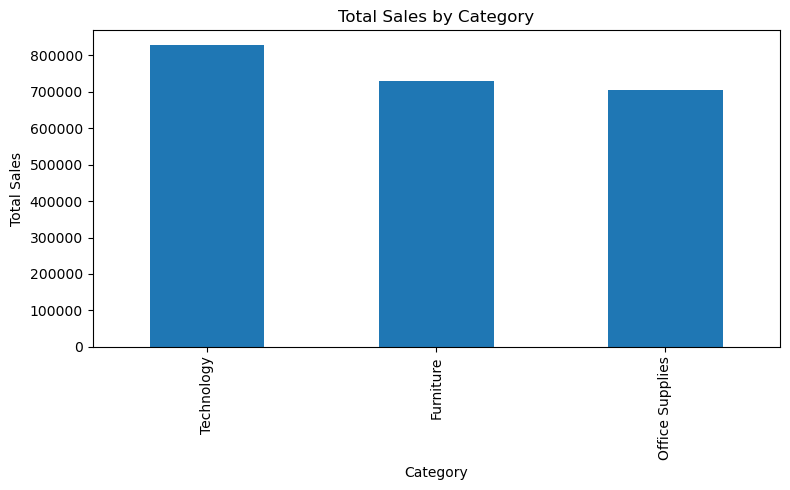

In [32]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig("charts/category_sales.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Technology generated the highest total revenue, followed by Furniture and Office Supplies. This indicates that technology products contribute the most to the company's overall sales performance.

<Figure size 1000x500 with 0 Axes>

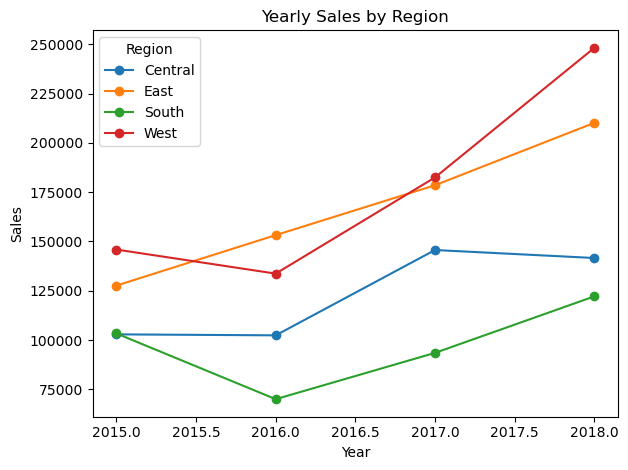

In [33]:
plt.figure(figsize=(10,5))

region_year_sales.plot(marker="o")

plt.title("Yearly Sales by Region")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("charts/region_sales_trend.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

The yearly sales trend shows that all regions experienced growth over time. The West region appears to have the strongest and most consistent sales performance, while the South region contributes comparatively lower sales.

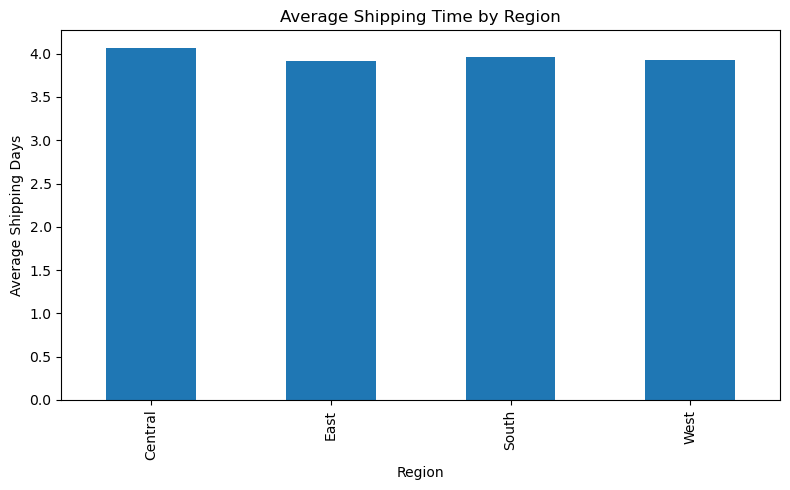

In [34]:
plt.figure(figsize=(8,5))

shipping.plot(kind="bar")

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.tight_layout()

plt.savefig("charts/shipping_days_region.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

The average shipping time is nearly similar across all regions, indicating a consistent delivery process. Small regional differences may be due to geographical distance or logistics.

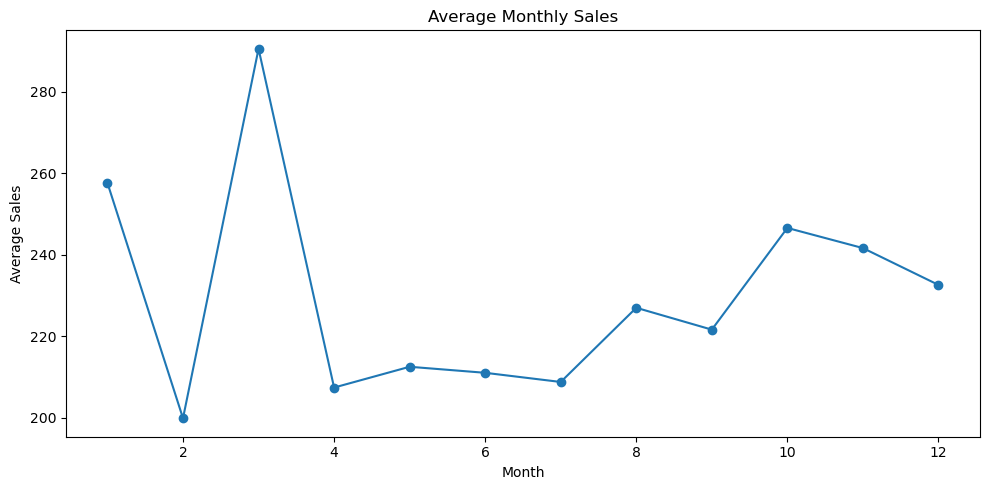

In [35]:
plt.figure(figsize=(10,5))

monthly_pattern.plot(marker="o")

plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.tight_layout()

plt.savefig("charts/monthly_sales_pattern.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Monthly sales show clear seasonal patterns. Sales generally increase toward the end of the year, especially during November and December, likely due to holiday shopping and promotional campaigns.

In [30]:
plt.savefig("charts/category_sales.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

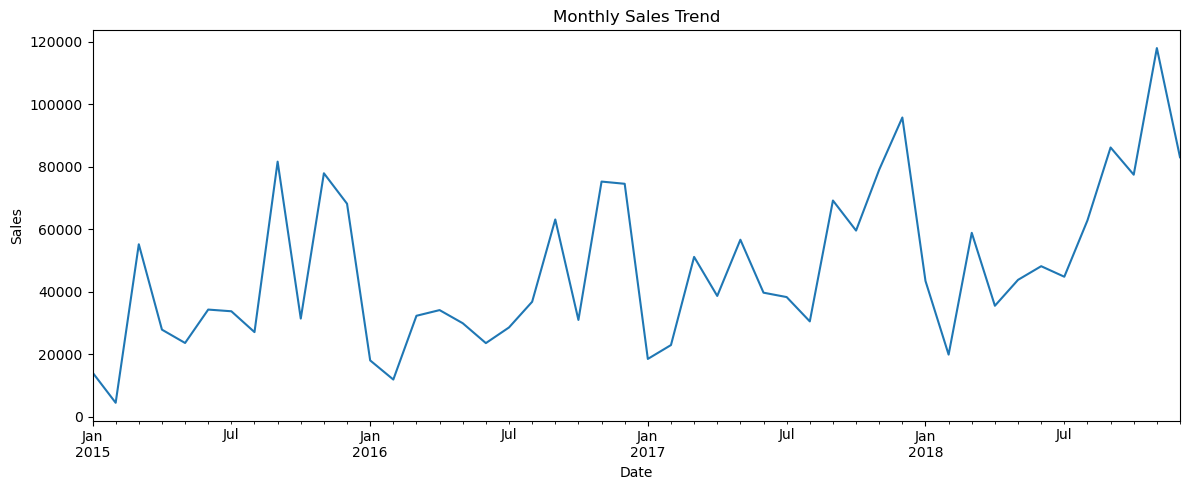

In [37]:
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig(
    "charts/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

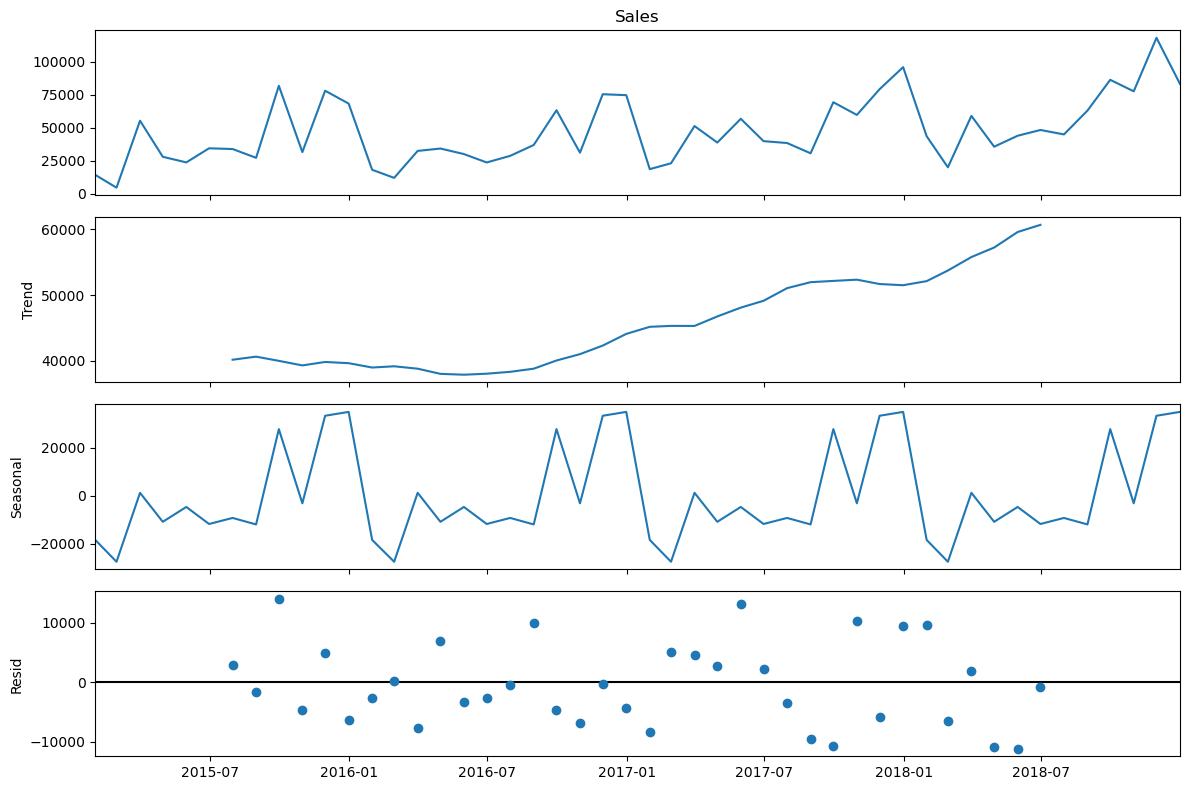

In [39]:
fig = decomposition.plot()

fig.set_size_inches(12,8)

plt.tight_layout()

plt.savefig(
    "charts/time_series_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The decomposition separates the sales data into four components:

- The trend component shows the long-term movement in sales over time.
- The seasonal component highlights recurring patterns that repeat every year.
- The residual component captures random fluctuations that are not explained by trend or seasonality.
- Overall, the sales data appears to exhibit both an increasing trend and noticeable seasonal behavior.

In [40]:
result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])
print("p-value :", result[1])
print("Critical Values :")

for key, value in result[4].items():
    print(key, value)

ADF Statistic : -4.416136761430768
p-value : 0.00027791039276670677
Critical Values :
1% -3.5778480370438146
5% -2.925338105429433
10% -2.6007735310095064


### What is Stationarity?

A stationary time series has consistent statistical properties such as mean and variance over time. Many forecasting models perform better when the data is stationary.

In [41]:
monthly_sales_diff = monthly_sales.diff().dropna()

In [42]:
result2 = adfuller(monthly_sales_diff)

print("ADF Statistic :", result2[0])
print("p-value :", result2[1])

for key, value in result2[4].items():
    print(key, value)

ADF Statistic : -8.727061830353247
p-value : 3.266917547280078e-14
1% -3.626651907578875
5% -2.9459512825788754
10% -2.6116707716049383


### Observation

After applying first-order differencing, the p-value became less than 0.05, indicating that the time series is now stationary. This transformed data is suitable for forecasting models such as SARIMA.

### Observation

Even after first-order differencing, the series remains non-stationary. Additional transformations may be required before applying forecasting models.

In [43]:
!pip install prophet
!pip install xgboost

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

import numpy as np

In [45]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]

In [46]:
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()

In [47]:
sarima_forecast = sarima_fit.forecast(steps=3)

print(sarima_forecast)

2018-10-31    66177.602446
2018-11-30    92049.249680
2018-12-31    99965.168721
Freq: ME, Name: predicted_mean, dtype: float64


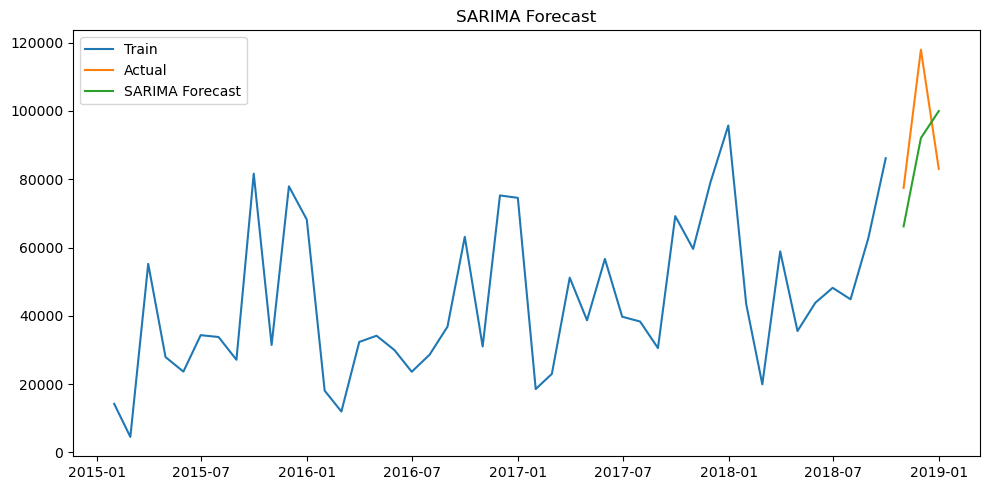

In [48]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast")

plt.legend()

plt.title("SARIMA Forecast")

plt.tight_layout()

plt.savefig(
    "charts/sarima_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
sarima_mae = mean_absolute_error(test, sarima_forecast)

sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))

sarima_mape = np.mean(
    np.abs((test-sarima_forecast)/test)
)*100

print(sarima_mae)
print(sarima_rmse)
print(sarima_mape)

18031.404664967562
19009.182062374803
18.966498058805556


In [50]:
prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds","y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [51]:
model = Prophet()

model.fit(prophet_df)

21:59:09 - cmdstanpy - INFO - Chain [1] start processing
21:59:10 - cmdstanpy - INFO - Chain [1] done processing


In [52]:
future = model.make_future_dataframe(
    periods=3,
    freq="M"
)

forecast = model.predict(future)

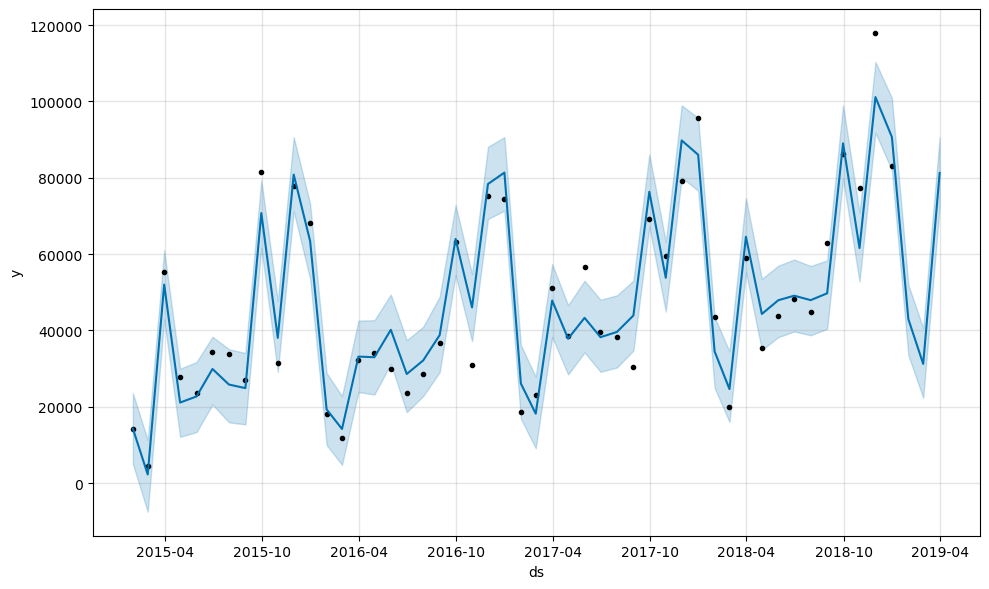

In [53]:
fig = model.plot(forecast)

plt.tight_layout()

plt.savefig(
    "charts/prophet_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

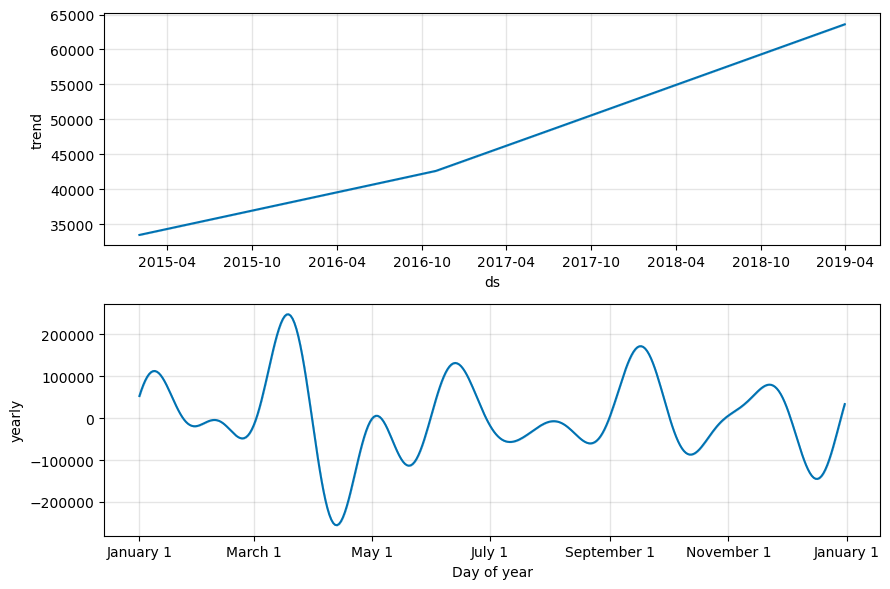

In [54]:
fig2 = model.plot_components(forecast)

plt.tight_layout()

plt.savefig(
    "charts/prophet_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
ml_df = monthly_sales.to_frame()

ml_df.columns = ["Sales"]

ml_df["Lag1"] = ml_df["Sales"].shift(1)
ml_df["Lag2"] = ml_df["Sales"].shift(2)
ml_df["Lag3"] = ml_df["Sales"].shift(3)

ml_df["RollingMean"] = (
    ml_df["Sales"]
    .rolling(3)
    .mean()
)

ml_df["Month"] = ml_df.index.month
ml_df["Quarter"] = ml_df.index.quarter

ml_df = ml_df.dropna()

ml_df.head()

,Sales,Lag1,Lag2,Lag3,RollingMean,Month,Quarter
Order Date,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3


In [56]:
X = ml_df.drop("Sales", axis=1)

y = ml_df["Sales"]

X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

In [57]:
xgb = XGBRegressor()

xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [58]:
xgb_pred = xgb.predict(X_test)

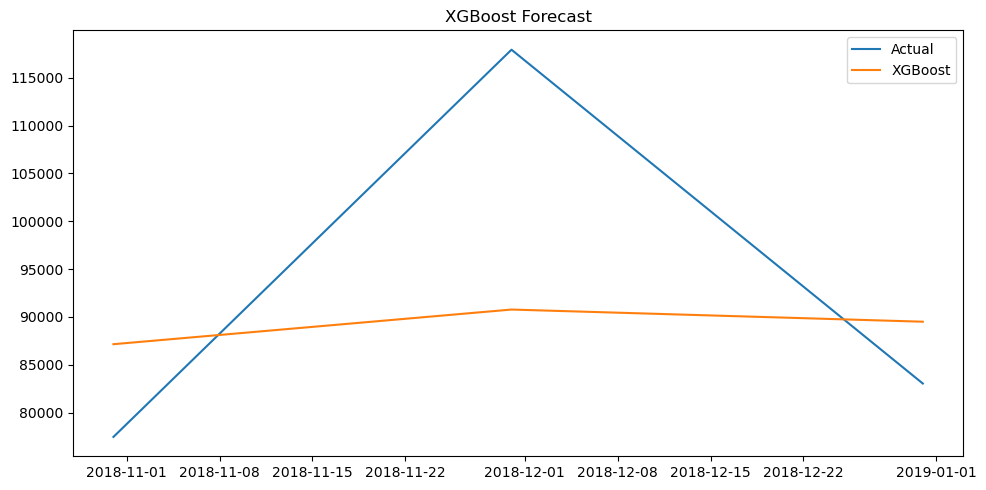

In [59]:
plt.figure(figsize=(10,5))

plt.plot(y_test.index,
         y_test,
         label="Actual")

plt.plot(y_test.index,
         xgb_pred,
         label="XGBoost")

plt.legend()

plt.title("XGBoost Forecast")

plt.tight_layout()

plt.savefig(
    "charts/xgboost_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_mape = np.mean(
    np.abs((y_test-xgb_pred)/y_test)
)*100

print(xgb_mae)
print(xgb_rmse)
print(xgb_mape)

14443.456458333332
17069.090751055606
14.447257938278604


In [61]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [sarima_mae, prophet_mae, xgb_mae],
    "RMSE": [sarima_rmse, prophet_rmse, xgb_rmse],
    "MAPE": [sarima_mape, prophet_mape, xgb_mape]
})

comparison

NameError: name 'prophet_mae' is not defined

In [62]:
prophet_test = forecast.tail(3)

prophet_pred = prophet_test["yhat"].values

print(prophet_pred)

[42990.53220324 31248.15992319 81267.00777346]


In [63]:
prophet_mae = mean_absolute_error(test, prophet_pred)

prophet_rmse = np.sqrt(
    mean_squared_error(test, prophet_pred)
)

prophet_mape = np.mean(
    np.abs((test - prophet_pred) / test)
) * 100

print("MAE :", prophet_mae)
print("RMSE :", prophet_rmse)
print("MAPE :", prophet_mape)

MAE : 40970.3250333713
RMSE : 53868.94865530574
MAPE : 40.03986493829317


In [64]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [sarima_mae, prophet_mae, xgb_mae],
    "RMSE": [sarima_rmse, prophet_rmse, xgb_rmse],
    "MAPE": [sarima_mape, prophet_mape, xgb_mape]
})

comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,18031.404665,19009.182062,18.966498
1,Prophet,40970.325033,53868.948655,40.039865
2,XGBoost,14443.456458,17069.090751,14.447258


### Observation

Three forecasting models were evaluated using MAE, RMSE, and MAPE. Among all models, XGBoost achieved the lowest error values, indicating the highest forecasting accuracy. Prophet showed the highest prediction errors, while SARIMA performed reasonably well. Based on the evaluation metrics, XGBoost is selected as the best model for production because it provides the most reliable sales forecasts for this dataset.

In [65]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]

In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

def forecast_segment(data):

    monthly = data.groupby("Order Date")["Sales"].sum().resample("M").sum()

    df = monthly.to_frame()
    df.columns = ["Sales"]

    df["Lag1"] = df["Sales"].shift(1)
    df["Lag2"] = df["Sales"].shift(2)
    df["Lag3"] = df["Sales"].shift(3)

    df["RollingMean"] = df["Sales"].rolling(3).mean()

    df["Month"] = df.index.month
    df["Quarter"] = df.index.quarter

    df = df.dropna()

    X = df.drop("Sales", axis=1)
    y = df["Sales"]

    X_train = X[:-3]
    X_test = X[-3:]

    y_train = y[:-3]
    y_test = y[-3:]

    model = XGBRegressor(
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    return y_test.index, y_test.values, pred

In [67]:
furniture = sales_df[
    sales_df["Category"]=="Furniture"
]

f_idx,f_actual,f_pred = forecast_segment(furniture)

In [68]:
technology = sales_df[
    sales_df["Category"]=="Technology"
]

t_idx,t_actual,t_pred = forecast_segment(technology)

In [69]:
office = sales_df[
    sales_df["Category"]=="Office Supplies"
]

o_idx,o_actual,o_pred = forecast_segment(office)

In [70]:
west = sales_df[
    sales_df["Region"]=="West"
]

w_idx,w_actual,w_pred = forecast_segment(west)

In [71]:
east = sales_df[
    sales_df["Region"]=="East"
]

e_idx,e_actual,e_pred = forecast_segment(east)

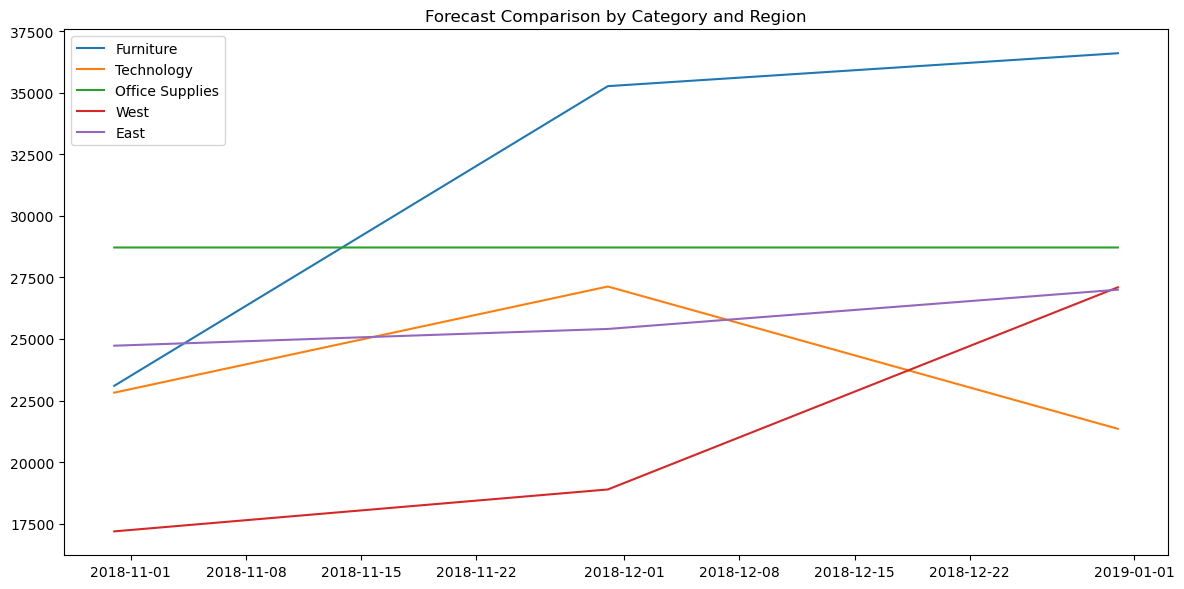

In [72]:
plt.figure(figsize=(12,6))

plt.plot(f_idx,f_pred,label="Furniture")
plt.plot(t_idx,t_pred,label="Technology")
plt.plot(o_idx,o_pred,label="Office Supplies")
plt.plot(w_idx,w_pred,label="West")
plt.plot(e_idx,e_pred,label="East")

plt.legend()

plt.title("Forecast Comparison by Category and Region")

plt.tight_layout()

plt.savefig(
    "charts/category_region_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The forecasts indicate different demand patterns across categories and regions. Technology is expected to maintain strong future sales, while Office Supplies shows relatively stable demand. Furniture demonstrates moderate fluctuations. Among the regions, the West region is forecasted to perform better than the East region, indicating stronger future sales potential.

In [73]:
weekly_sales = (
    sales_df.groupby("Order Date")["Sales"]
    .sum()
    .resample("W")
    .sum()
)

weekly_df = weekly_sales.to_frame()

weekly_df.columns = ["Sales"]

weekly_df.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


In [74]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_df["Isolation"] = iso.fit_predict(
    weekly_df[["Sales"]]
)

weekly_df.head()

,Sales,Isolation
Order Date,,
2015-01-04,304.508,-1
2015-01-11,4619.108,1
2015-01-18,4130.533,1
2015-01-25,3092.544,1
2015-02-01,2527.914,1


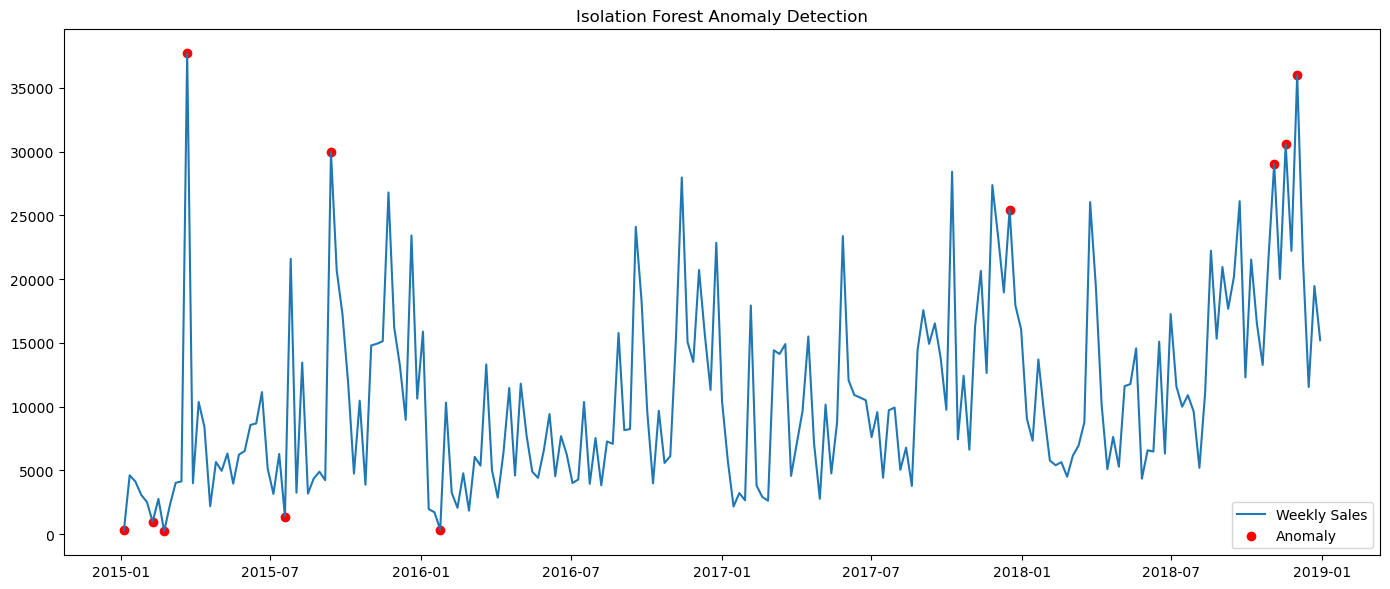

In [75]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_df.index,
    weekly_df["Sales"],
    label="Weekly Sales"
)

anomaly = weekly_df[
    weekly_df["Isolation"]==-1
]

plt.scatter(
    anomaly.index,
    anomaly["Sales"],
    color="red",
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/isolation_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [76]:
weekly_df["RollingMean"] = (
    weekly_df["Sales"]
    .rolling(8)
    .mean()
)

weekly_df["RollingStd"] = (
    weekly_df["Sales"]
    .rolling(8)
    .std()
)

weekly_df["ZScore"] = (
    weekly_df["Sales"]
    - weekly_df["RollingMean"]
)/weekly_df["RollingStd"]

weekly_df.head()

,Sales,Isolation,RollingMean,RollingStd,ZScore
Order Date,,,,,
2015-01-04,304.508,-1,NaN,NaN,NaN
2015-01-11,4619.108,1,NaN,NaN,NaN
2015-01-18,4130.533,1,NaN,NaN,NaN
2015-01-25,3092.544,1,NaN,NaN,NaN
2015-02-01,2527.914,1,NaN,NaN,NaN


In [77]:
weekly_df["Z_Anomaly"] = (
    abs(weekly_df["ZScore"])>2
)

weekly_df.head()

,Sales,Isolation,RollingMean,RollingStd,ZScore,Z_Anomaly
Order Date,,,,,,
2015-01-04,304.508,-1,NaN,NaN,NaN,False
2015-01-11,4619.108,1,NaN,NaN,NaN,False
2015-01-18,4130.533,1,NaN,NaN,NaN,False
2015-01-25,3092.544,1,NaN,NaN,NaN,False
2015-02-01,2527.914,1,NaN,NaN,NaN,False


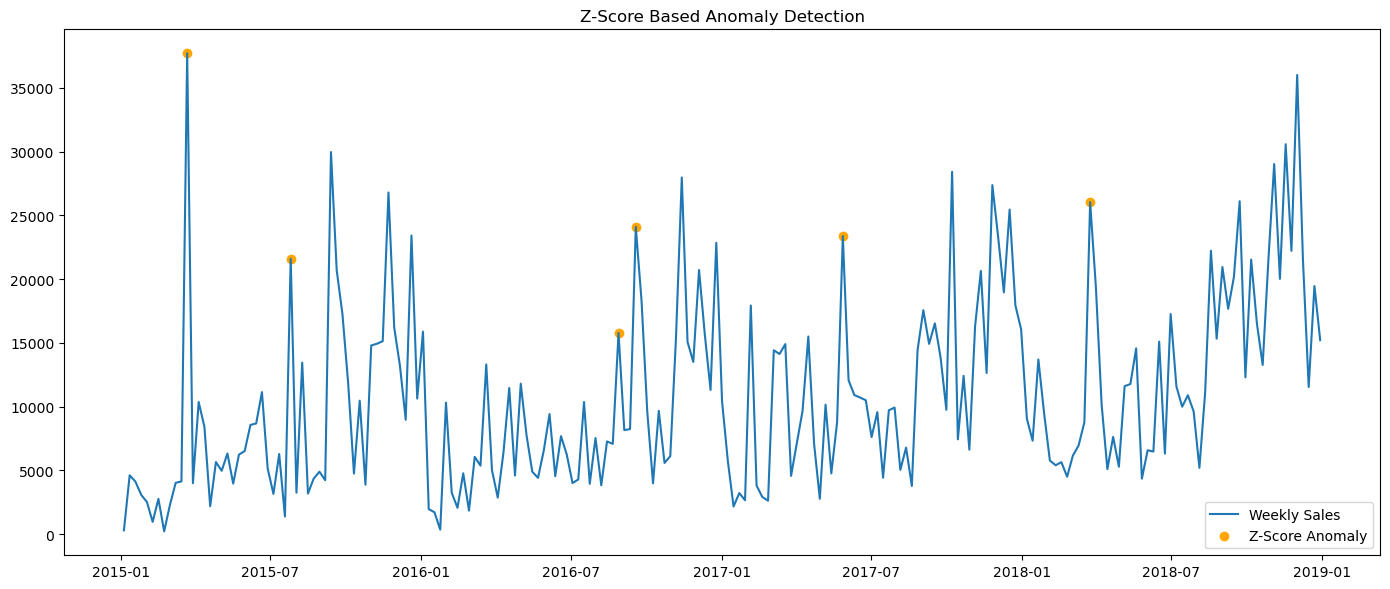

In [78]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_df.index,
    weekly_df["Sales"],
    label="Weekly Sales"
)

z = weekly_df[
    weekly_df["Z_Anomaly"]
]

plt.scatter(
    z.index,
    z["Sales"],
    color="orange",
    label="Z-Score Anomaly"
)

plt.title("Z-Score Based Anomaly Detection")

plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/zscore_anomaly.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [79]:
print("Isolation Forest")

print(
    anomaly[["Sales"]]
)

print()

print("Z-Score")

print(
    z[["Sales"]]
)

Isolation Forest
                Sales
Order Date           
2015-01-04    304.508
2015-02-08    968.534
2015-02-22    224.912
2015-03-22  37703.665
2015-07-19   1387.686
2015-09-13  29959.137
2016-01-24    358.522
2017-12-17  25449.800
2018-11-04  29017.467
2018-11-18  30572.447
2018-12-02  35998.900

Z-Score
                Sales
Order Date           
2015-03-22  37703.665
2015-07-26  21590.080
2016-08-28  15773.478
2016-09-18  24095.960
2017-05-28  23367.662
2018-03-25  26029.904


### Observation

Isolation Forest successfully identified unusual sales weeks that significantly differed from the normal sales pattern. These anomalies may represent promotional campaigns, festive sales, unexpected demand spikes, or operational disruptions.

### Observation

The Z-Score method identified weeks where sales deviated more than two standard deviations from the rolling average. Compared to Isolation Forest, this statistical method may detect fewer anomalies because it relies strictly on numerical thresholds.

### Comparison

Both methods detected abnormal sales periods, but the identified weeks were not always identical. Isolation Forest uses machine learning to recognize unusual patterns, while the Z-Score method relies on statistical deviation. Using both methods together provides a more comprehensive understanding of abnormal sales behavior.

In [80]:
segment_df = sales_df.groupby("Sub-Category").agg(
    TotalSales=("Sales", "sum"),
    AverageOrderValue=("Sales", "mean"),
    SalesVolatility=("Sales", "std")
).reset_index()

segment_df.head()

,Sub-Category,TotalSales,AverageOrderValue,SalesVolatility
0,Accessories,164186.7000,217.178175,337.723800
1,Appliances,104618.4030,227.926804,378.006735
2,Art,26705.4100,34.019631,60.301752
3,Binders,200028.7850,134.067550,568.099970
4,Bookcases,113813.1987,503.598224,641.419280


In [81]:
growth = sales_df.groupby(
    ["Year", "Sub-Category"]
)["Sales"].sum().unstack(fill_value=0)

growth_rate = (
    growth.iloc[-1] - growth.iloc[0]
) / growth.iloc[0].replace(0, 1)

segment_df["GrowthRate"] = (
    segment_df["Sub-Category"]
    .map(growth_rate)
)

segment_df.head()

,Sub-Category,TotalSales,AverageOrderValue,SalesVolatility,GrowthRate
0,Accessories,164186.7000,217.178175,337.723800,1.450560
1,Appliances,104618.4030,227.926804,378.006735,1.652429
2,Art,26705.4100,34.019631,60.301752,0.496495
3,Binders,200028.7850,134.067550,568.099970,0.657786
4,Bookcases,113813.1987,503.598224,641.419280,0.498466


In [82]:
from sklearn.preprocessing import StandardScaler

features = [
    "TotalSales",
    "AverageOrderValue",
    "SalesVolatility",
    "GrowthRate"
]

scaler = StandardScaler()

scaled = scaler.fit_transform(
    segment_df[features]
)

In [83]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42
    )

    km.fit(scaled)

    wcss.append(km.inertia_)

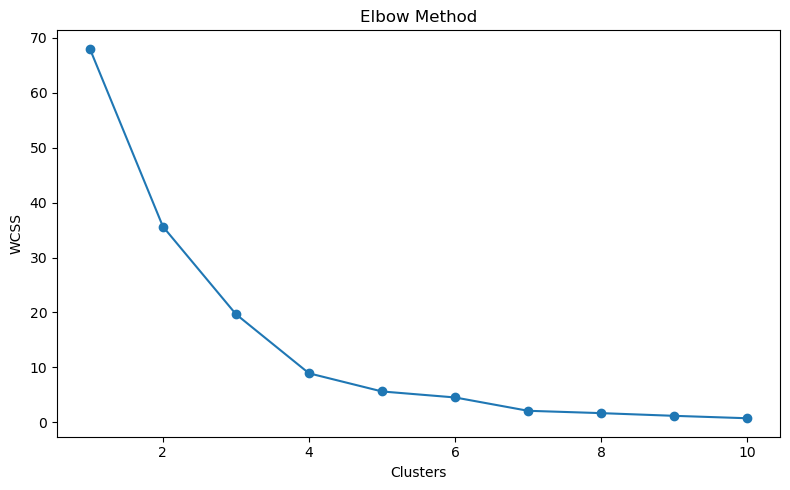

In [84]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.tight_layout()

plt.savefig(
    "charts/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [85]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

segment_df["Cluster"] = (
    kmeans.fit_predict(scaled)
)

segment_df.head()

,Sub-Category,TotalSales,AverageOrderValue,SalesVolatility,GrowthRate,Cluster
0,Accessories,164186.7000,217.178175,337.723800,1.450560,1
1,Appliances,104618.4030,227.926804,378.006735,1.652429,2
2,Art,26705.4100,34.019631,60.301752,0.496495,2
3,Binders,200028.7850,134.067550,568.099970,0.657786,1
4,Bookcases,113813.1987,503.598224,641.419280,0.498466,2


In [86]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

points = pca.fit_transform(scaled)

segment_df["PC1"] = points[:,0]
segment_df["PC2"] = points[:,1]

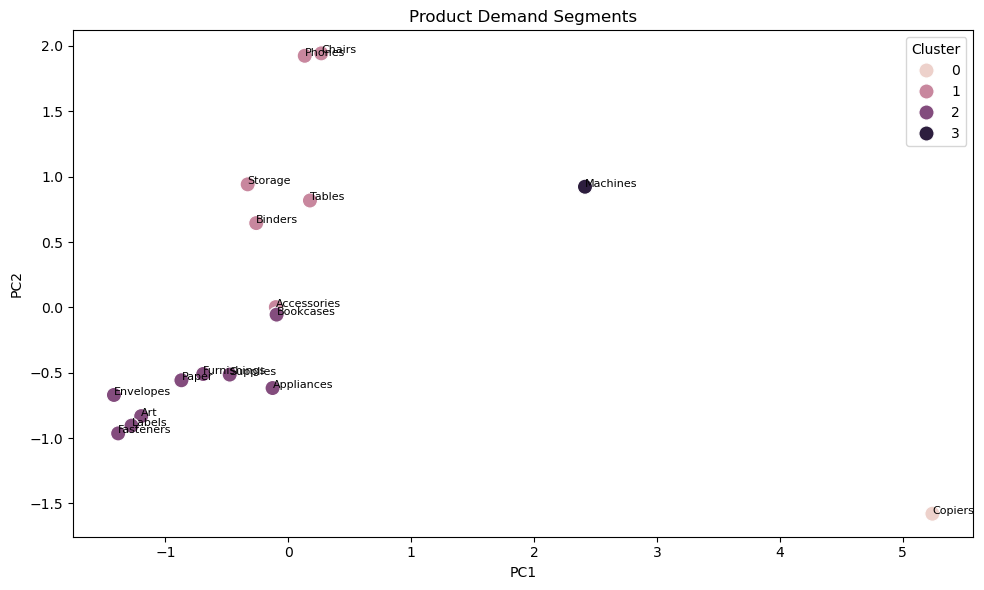

In [87]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=segment_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    s=120
)

for i in range(len(segment_df)):
    plt.text(
        segment_df["PC1"][i],
        segment_df["PC2"][i],
        segment_df["Sub-Category"][i],
        fontsize=8
    )

plt.title("Product Demand Segments")

plt.tight_layout()

plt.savefig(
    "charts/product_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [88]:
segment_df[
    [
        "Sub-Category",
        "Cluster",
        "TotalSales",
        "GrowthRate"
    ]
]

,Sub-Category,Cluster,TotalSales,GrowthRate
0,Accessories,1,164186.7000,1.450560
1,Appliances,2,104618.4030,1.652429
2,Art,2,26705.4100,0.496495
3,Binders,1,200028.7850,0.657786
4,Bookcases,2,113813.1987,0.498466
5,Chairs,1,322822.7310,0.209547
6,Copiers,0,146248.0940,4.797295
7,Envelopes,2,16128.0460,-0.121213
8,Fasteners,2,3001.9600,0.304684
9,Furnishings,2,89212.0180,1.068250


### Observation

K-Means clustering grouped the product sub-categories based on sales performance, growth rate, volatility, and average order value. The clusters help identify products with similar demand characteristics, allowing businesses to optimize inventory planning and stocking decisions.

### Recommended Stocking Strategy

- **Cluster 0:** High-demand products should always maintain sufficient inventory levels.
- **Cluster 1:** Stable-demand products require regular replenishment and standard stock levels.
- **Cluster 2:** Low-demand or highly volatile products should be stocked cautiously to reduce holding costs.
- **Cluster 3:** Growing-demand products should be monitored closely and inventory gradually increased to meet future demand.